# Validación

- Objetivo: Validar el modelo seleccionado durante la etapa de entrenamiento y optimización.

Se evaluará el desempeño del modelo sobre el conjunto de prueba mediante:

- Matriz de confusión.
- Curva ROC y AUC.
- Importancia de variables.
- Análisis de resultados.

El modelo validado será utilizado posteriormente para generar las predicciones finales del TP2.-


# Importación de Librerias

In [12]:
import pandas as pd
import numpy as np

from pathlib import Path
import joblib

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# PATHS

In [13]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

# Verificación PATHS

In [14]:
print("PROJECT_ROOT :", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("MODELS_DIR   :", MODELS_DIR)

print("\nVerificación de existencia:")

print("Processed existe:", PROCESSED_DIR.exists())
print("Models existe   :", MODELS_DIR.exists())

MODEL_FILE = MODELS_DIR / "random_forest_final.pkl"

print("Modelo existe:", MODEL_FILE.exists())
print("Ruta modelo  :", MODEL_FILE)

PROJECT_ROOT : c:\Users\sdecicco\OneDrive - loteriadelaciudad.gob.ar\Escritorio\Diplomatura en IA\TP2
PROCESSED_DIR: c:\Users\sdecicco\OneDrive - loteriadelaciudad.gob.ar\Escritorio\Diplomatura en IA\TP2\data\processed
MODELS_DIR   : c:\Users\sdecicco\OneDrive - loteriadelaciudad.gob.ar\Escritorio\Diplomatura en IA\TP2\models

Verificación de existencia:
Processed existe: True
Models existe   : True
Modelo existe: True
Ruta modelo  : c:\Users\sdecicco\OneDrive - loteriadelaciudad.gob.ar\Escritorio\Diplomatura en IA\TP2\models\random_forest_final.pkl


# Cargar DataSets

In [15]:
X_test = pd.read_csv(PROCESSED_DIR / "X_test.csv")
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv")

y_test = y_test.squeeze()

# Cargar modelo ganador

In [16]:
rf = joblib.load(MODELS_DIR / "random_forest_final.pkl")

print("Modelo cargado correctamente.")

Modelo cargado correctamente.


# Generar predicciones

In [17]:
y_pred = rf.predict(X_test)

print("Predicciones generadas correctamente.")

Predicciones generadas correctamente.


# Verificación rápida

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      6334
           1       0.71      0.76      0.73      3666

    accuracy                           0.80     10000
   macro avg       0.78      0.79      0.78     10000
weighted avg       0.80      0.80      0.80     10000



# Matriz de Confusión

- La matriz de confusión permite analizar el desempeño del modelo clasificando correctamente e incorrectamente cada una de las clases.

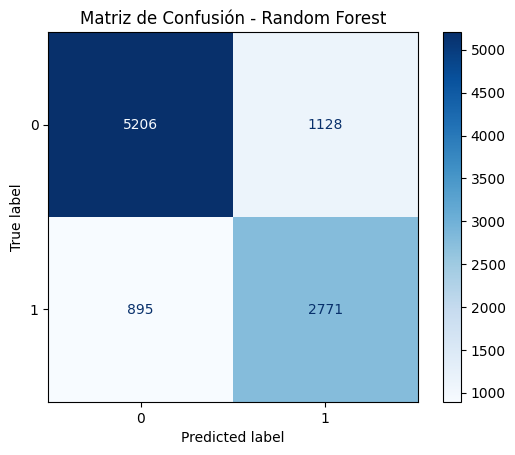

In [19]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Matriz de Confusión - Random Forest")
plt.show()

# Conclusiones de la Matriz de Confusión

- La matriz de confusión muestra un comportamiento equilibrado entre ambas clases. El modelo logró clasificar correctamente 5.206 registros de la clase 0 y 2.771 registros de la clase 1.

- Asimismo, se observan 1.128 falsos positivos y 895 falsos negativos. La diferencia relativamente baja entre ambos tipos de error indica que el modelo no presenta una tendencia marcada a favorecer una clase sobre la otra.

- Estos resultados son consistentes con las métricas obtenidas previamente, donde el modelo alcanzó un F1 Score cercano a 0.73 para la clase objetivo, mostrando un desempeño adecuado para el problema planteado.


# Curva ROC y AUC

- La curva ROC permite analizar la capacidad discriminatoria del modelo para separar ambas clases a distintos umbrales de decisión.

- El área bajo la curva (AUC) resume dicho comportamiento mediante un único indicador.

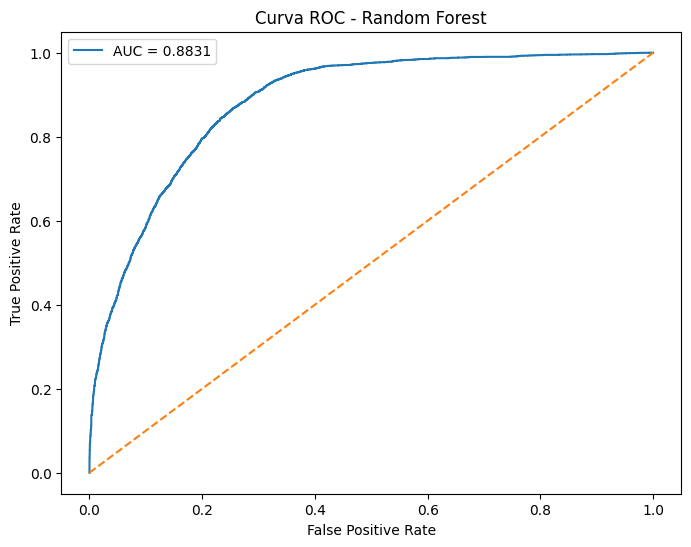

AUC: 0.8831


In [20]:
y_prob = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest")
plt.legend()

plt.show()

print(f"AUC: {auc:.4f}")

# AUC	Interpretación

0.50	Aleatorio
0.60 - 0.70	Bajo
0.70 - 0.80	Aceptable
0.80 - 0.90	Muy bueno
> 0.90	Excelente

# Curva ROC y AUC

- La curva ROC muestra la capacidad del modelo para distinguir entre ambas clases a distintos umbrales de decisión.

- El modelo Random Forest obtuvo un AUC de 0.8831, valor que indica una muy buena capacidad discriminatoria. La curva se mantiene claramente por encima de la diagonal correspondiente a un clasificador aleatorio, evidenciando que el modelo logra separar correctamente la mayoría de los casos positivos y negativos.

- Si bien el F1 Score obtenido sobre el conjunto de prueba fue cercano a 0.73, el valor de AUC sugiere que el modelo conserva información predictiva relevante y que podría ajustarse el umbral de clasificación en función de necesidades específicas del negocio.


# Importancia de Variables

- Una de las ventajas de los modelos basados en árboles es que permiten estimar la importancia relativa de cada variable en el proceso de clasificación.

- Esta información ayuda a comprender qué atributos influyen en mayor medida sobre las predicciones generadas por el modelo.

In [21]:
feature_importance = pd.DataFrame({
    "Variable": X_test.columns,
    "Importancia": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importancia",
    ascending=False
)

feature_importance.head(15)

,Variable,Importancia
0,gender,0.127868
21,Gtp,0.093601
2,height(cm),0.078036
13,triglyceride,0.069094
16,hemoglobin,0.063448
15,LDL,0.048722
12,Cholesterol,0.046902
14,HDL,0.046896
20,ALT,0.046233
11,fasting blood sugar,0.045864


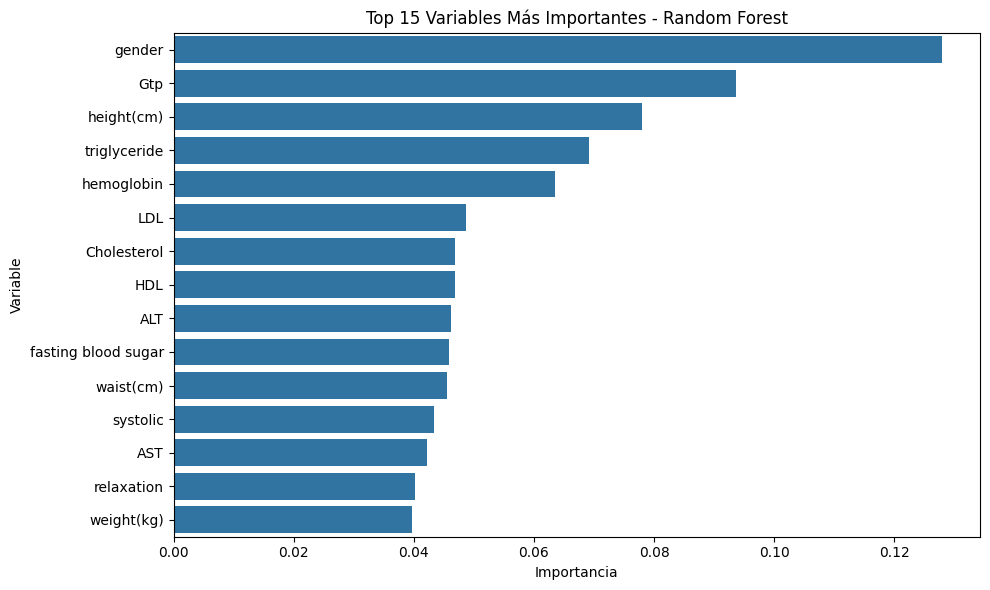

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importancia",
    y="Variable"
)

plt.title("Top 15 Variables Más Importantes - Random Forest")
plt.tight_layout()

plt.show()

# Importancia de Variables

- El análisis de importancia de variables permitió identificar los atributos que tuvieron mayor influencia sobre las predicciones del modelo Random Forest.

- La variable más relevante fue `gender`, seguida por variables clínicas y antropométricas como `Gtp`, `height(cm)`, `triglyceride`, `hemoglobin`, `LDL`, `Cholesterol`, `HDL`, `ALT` y `AST`.

- Estos resultados son consistentes con algunos de los hallazgos observados durante el EDA, donde variables como `gender` y diversos indicadores sanguíneos mostraban diferencias relevantes entre las clases.

- Asimismo, la importancia se encuentra distribuida entre múltiples variables, evitando una dependencia excesiva de un único atributo y aportando mayor robustez al modelo frente a posibles cambios en los datos futuros.


# Conclusión General de la Validación

- A partir del proceso de entrenamiento y validación realizado, el modelo Random Forest fue seleccionado como la mejor alternativa entre los modelos evaluados, alcanzando un F1 Score cercano a 0.73 sobre el conjunto de prueba y un AUC de 0.88, evidenciando una buena capacidad para discriminar entre ambas clases.

- Los resultados obtenidos durante la validación muestran coherencia con los hallazgos observados previamente en el EDA. En aquella etapa se identificó que variables como `gender`, `hemoglobin`, `dental caries` y `tartar` presentaban asociaciones relevantes con la variable objetivo. Posteriormente, durante el entrenamiento del modelo, se observó que `gender` se mantuvo como uno de los atributos más influyentes para la clasificación.

- Asimismo, durante el análisis exploratorio se detectaron valores atípicos en variables clínicas como `Gtp`, `ALT` y `AST`. Se decidió conservar dichos registros debido a que podrían representar información válida del dominio y no necesariamente errores de medición. El análisis de importancia de variables realizado sobre el modelo validado confirmó que varias de estas variables aportan información relevante para la predicción, justificando la decisión de no eliminarlas durante el preprocesamiento.

- Respecto de los registros duplicados, se optó por mantenerlos en esta etapa debido a que no se contaba con evidencia suficiente para considerarlos errores o inconsistencias. Esta decisión permitió preservar la totalidad de la información disponible para el entrenamiento de los modelos.

- En conjunto, los resultados obtenidos sugieren que el modelo logra capturar patrones significativos presentes en los datos, manteniendo un equilibrio razonable entre capacidad predictiva y generalización, constituyendo una base sólida para la generación de predicciones sobre nuevos registros.
